In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, 
                             classification_report, confusion_matrix)

print("All libraries imported!")

All libraries imported!


In [5]:
# Download directly — no Kaggle needed!
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Dataset loaded!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded!
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

In [7]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nChurn distribution:\n{df['Churn'].value_counts()}")

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


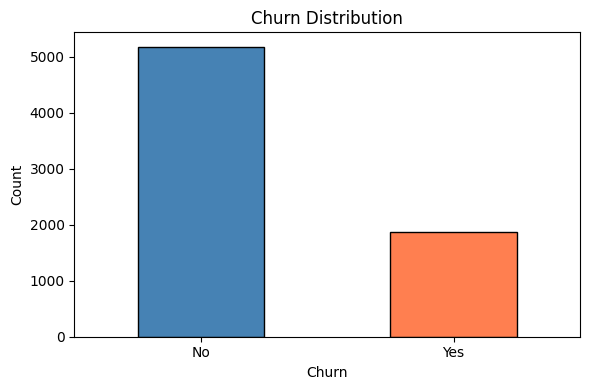

In [8]:
plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
# Drop customerID (not useful)
df.drop('customerID', axis=1, inplace=True)

# Fix TotalCharges (it has spaces, convert to numeric)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode target variable
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Encode all categorical columns
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Preprocessing complete!")
print(df.shape)
df.head()

Preprocessing complete!
(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


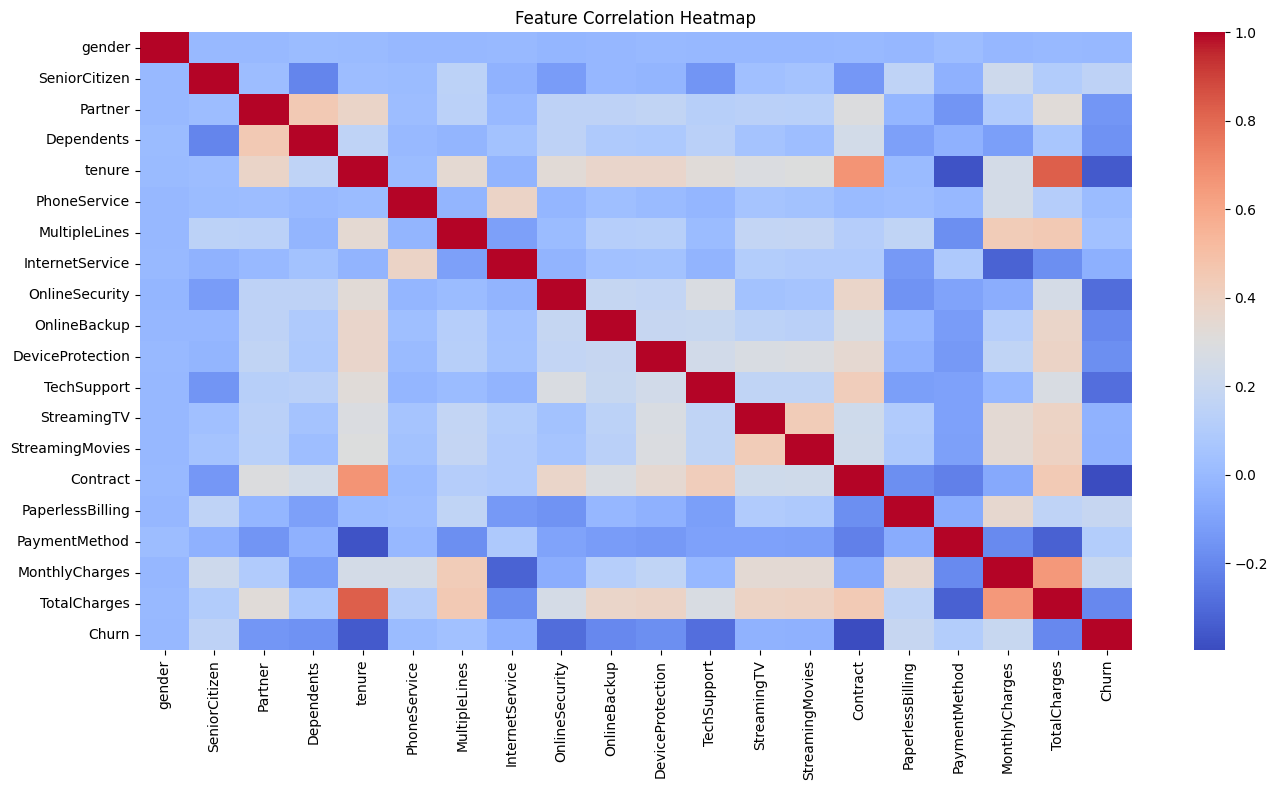

In [10]:
plt.figure(figsize=(14, 8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [11]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Training samples : 5634
Testing samples  : 1409


In [12]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)

lr_acc = accuracy_score(y_test, lr_preds)
lr_f1  = f1_score(y_test, lr_preds)

print("=== Logistic Regression Results ===")
print(f"Accuracy : {lr_acc * 100:.2f}%")
print(f"F1 Score : {lr_f1 * 100:.2f}%")

=== Logistic Regression Results ===
Accuracy : 79.91%
F1 Score : 59.16%


In [13]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
rf_f1  = f1_score(y_test, rf_preds)

print("=== Random Forest Results ===")
print(f"Accuracy : {rf_acc * 100:.2f}%")
print(f"F1 Score : {rf_f1 * 100:.2f}%")

=== Random Forest Results ===
Accuracy : 79.06%
F1 Score : 55.90%


In [14]:
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_preds = grid_search.best_estimator_.predict(X_test)
best_acc = accuracy_score(y_test, best_preds)
best_f1  = f1_score(y_test, best_preds)

print(f"\nBest Parameters : {grid_search.best_params_}")
print(f"Best Accuracy   : {best_acc * 100:.2f}%")
print(f"Best F1 Score   : {best_f1 * 100:.2f}%")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Parameters : {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}
Best Accuracy   : 80.27%
Best F1 Score   : 58.75%


In [15]:
print("=== Detailed Classification Report (Best Model) ===")
print(classification_report(y_test, best_preds, 
                            target_names=['No Churn', 'Churn']))

=== Detailed Classification Report (Best Model) ===
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



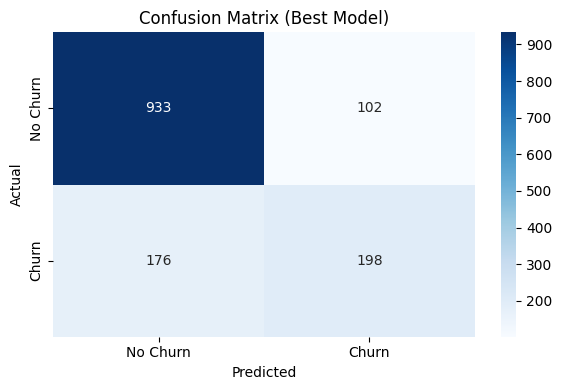

In [16]:
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix (Best Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

                 Model  Accuracy (%)  F1 Score (%)
0  Logistic Regression         79.91         59.16
1        Random Forest         79.06         55.90
2      RF + GridSearch         80.27         58.75


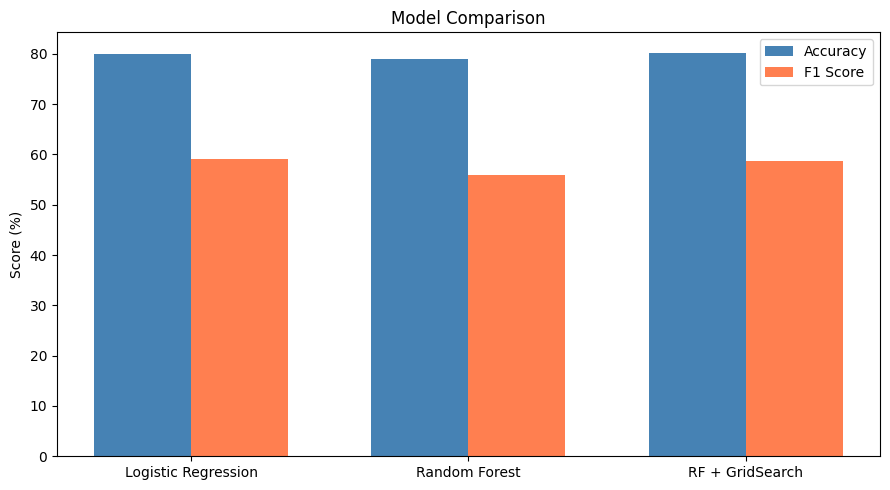

In [17]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'RF + GridSearch'],
    'Accuracy (%)': [round(lr_acc*100, 2), round(rf_acc*100, 2), round(best_acc*100, 2)],
    'F1 Score (%)': [round(lr_f1*100, 2), round(rf_f1*100, 2), round(best_f1*100, 2)]
})

print(results)

# Plot
x = np.arange(3)
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, results['Accuracy (%)'], width, label='Accuracy', color='steelblue')
ax.bar(x + width/2, results['F1 Score (%)'], width, label='F1 Score', color='coral')
ax.set_title('Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.set_ylabel('Score (%)')
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# Save the best model pipeline
joblib.dump(grid_search.best_estimator_, 'churn_pipeline.pkl')
print("Pipeline saved as churn_pipeline.pkl ✅")

# Test loading it back
loaded_pipeline = joblib.load('churn_pipeline.pkl')
test_preds = loaded_pipeline.predict(X_test)
print(f"Loaded pipeline accuracy: {accuracy_score(y_test, test_preds) * 100:.2f}%")
print("Pipeline reloaded successfully ✅")

Pipeline saved as churn_pipeline.pkl ✅
Loaded pipeline accuracy: 80.27%
Pipeline reloaded successfully ✅
